# 🌫️ Advanced Darkroom: Grain Diffusion

### Welcome, Master Printers!
Grain is an inherent part of the photographic process. Without grain, we wouldn't have photographs[cite: 5]. However, there are times when excessive grain can become an impediment to creative photography, especially in continuous midtones like skies or human flesh[cite: 5].

To minimize grain, we first need to understand what we are actually looking at on the paper.
* **The Illusion of Grain:** The black clumps you see in a photographic print are not actually the silver grains of the negative[cite: 5]. They are the *spaces between* the grains of the negative[cite: 5]. 
* **The Reality:** The actual silver grain on the negative blocks light from the enlarger, meaning the grain itself appears *white* in the final photograph[cite: 5].

Knowing where the grain structure comes from gives us a hint on how to deal with it: if we can take the light passing through the spaces between the grain and gently spread (diffuse) it into the surrounding white areas, the apparent graininess will be minimized[cite: 5].

## Step 1: The Two-Exposure Technique
Grain diffusion is a precise two-exposure technique performed in the darkroom[cite: 5]. 

**1. The Main Exposure (Sharp)**
The first exposure is made normally to capture the sharp details of the image, but the time is cut back[cite: 5]. A good starting point is cutting the maximum black exposure by about 33 percent[cite: 5].

**2. The Diffusion Exposure (Soft)**
The second exposure provides the remaining 33 percent of the light, but it is done through a diffusion material, such as crinkled plastic food wrap[cite: 5]. 
* The negative must remain in the enlarger during this step[cite: 5].
* The diffusion material is held under the lens and moved in a circular motion during the exposure[cite: 5].
* This exposure is usually made one stop lower (e.g., changing the aperture from f/11 to f/16) for the same amount of time, effectively halving the light intensity to make up the remaining 33% of the total exposure[cite: 5].

### Why not just remove the negative?
Some photographers remove the negative for the second exposure, but this is a mistake. Doing so simply exposes the whole paper to nonimage light, which is just flashing the paper[cite: 5]. Flashing reduces contrast, and if you then use a contrast filter to compensate for the lost contrast, you will actually *increase* the apparent grain, canceling out all your hard work[cite: 5]!

## Step 2: The Visual Physics of Diffusion
When done properly, this technique brings the shadows to their maximum black while "spreading out" the grain pattern to soften the individual grains[cite: 5]. The grain won't magically disappear, but it will be subtly and beautifully minimized[cite: 5]. Furthermore, the overall print contrast should not be noticeably affected[cite: 5].

Let's use Python to simulate the physics of how a sharp main exposure combined with a diffused secondary exposure smooths out high-frequency film grain!

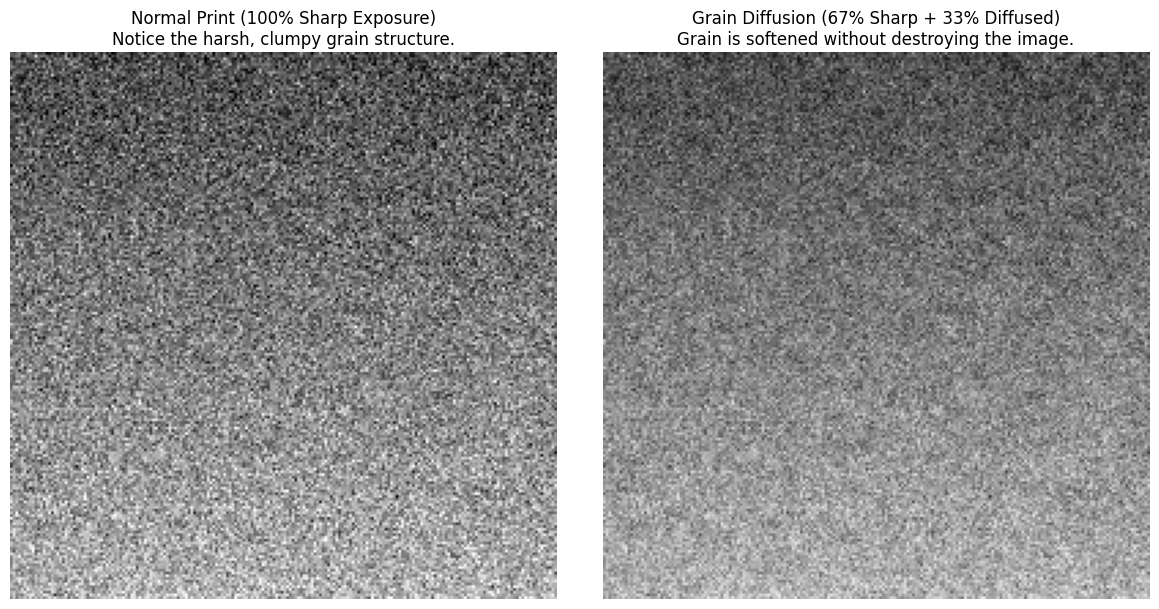

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

def simulate_grain_diffusion():
    """
    Simulates the visual physics of the two-exposure Grain Diffusion technique.
    Compares a 100% sharp exposure to a 67% sharp + 33% diffused exposure.
    """
    # 1. Create a synthetic "mid-tone" image (e.g., a patch of sky or skin)
    image_size = 200
    base_image = np.linspace(0.3, 0.7, image_size * image_size).reshape(image_size, image_size)
    
    # 2. Add heavy film grain (high-frequency noise)
    # The noise simulates the white grains and black spaces of a physical print
    np.random.seed(42)
    grain_noise = np.random.normal(0, 0.15, base_image.shape)
    grainy_image = np.clip(base_image + grain_noise, 0, 1)

    # 3. Simulate Normal Print (100% Sharp Exposure)
    normal_print = grainy_image

    # 4. Simulate Grain Diffusion Technique
    # Exposure 1: 67% of the sharp grainy image
    exposure_1_sharp = grainy_image * 0.67
    
    # Exposure 2: 33% of the image, passed through a physical diffuser (plastic wrap)
    # We simulate the light scattering of the plastic wrap using a Gaussian blur
    scattered_light = gaussian_filter(grainy_image, sigma=2.0)
    exposure_2_diffused = scattered_light * 0.33
    
    # Combine the exposures on the photographic paper
    diffused_print = exposure_1_sharp + exposure_2_diffused

    # 5. Visualization
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Normal Print
    axes[0].imshow(normal_print, cmap='gray', vmin=0, vmax=1)
    axes[0].set_title("Normal Print (100% Sharp Exposure)\nNotice the harsh, clumpy grain structure.", fontsize=12)
    axes[0].axis('off')

    # Diffused Print
    axes[1].imshow(diffused_print, cmap='gray', vmin=0, vmax=1)
    axes[1].set_title("Grain Diffusion (67% Sharp + 33% Diffused)\nGrain is softened without destroying the image.", fontsize=12)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# Run the grain diffusion simulator!
simulate_grain_diffusion()